In [ ]:
import torch
import numpy as np
import torchvision
import torch.nn as nn
from torchvision.datasets import mnist

In [ ]:
import torchvision
from torch.utils.data import Subset

transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    # CIFAR-10 images are 3 channels, we need to handle this in the model or convert to grayscale if preferred
    # For now, keeping 3 channels and will adapt the model later if needed.
    # torchvision.transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Optional: Add normalization if needed for your model
])

# Load the full CIFAR-10 training data
full_train_data = torchvision.datasets.CIFAR10(root="./data", train=True, transform=transform, download=True)

# Filter the dataset to include only images with a specific label (e.g., class 3 - cat)
# You can change the class index (e.g., 0 for airplane, 1 for automobile, etc.)
# See https://www.cs.toronto.edu/~kriz/cifar.html for class labels
target_class_index = 3 # Example: Class 3 is 'cat'
target_class_indices = [i for i, (image, label) in enumerate(full_train_data) if label == target_class_index]
train_data_target_class = Subset(full_train_data, target_class_indices)

# Use the filtered dataset for training
train_data = train_data_target_class

In [ ]:
def Noising(data_tensor, num_steps, theta = 4):
    for i in range(num_steps):
        data_tensor = theta * data_tensor * (1 - data_tensor)
    noisy_image = data_tensor
    return noisy_image

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# CNN Encoder to extract style/latent code z
class CNNEncoder(nn.Module):
    def __init__(self, img_channels=3, z_dim=32): # Changed img_channels to 3
        super().__init__()
        self.conv1 = nn.Conv2d(img_channels, 16, 3, stride=2, padding=1)  # (B, 16, 16, 16)
        self.conv2 = nn.Conv2d(16, 32, 3, stride=2, padding=1)            # (B, 32, 8, 8)
        self.conv3 = nn.Conv2d(32, 64, 3, stride=2, padding=1)            # (B, 64, 4, 4)
        self.fc = nn.Linear(64 * 4 * 4, z_dim)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        z = self.fc(x)
        return z


# FeedForward model that takes flattened image + z vector
class DeepModel(nn.Module):
    def __init__(self, shape=torch.tensor([3 * 32 * 32]), hidden_dim=128, z_dim=32): # Changed shape to 3*32*32
        super().__init__()
        input_dim = shape.prod().item() + z_dim
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc3 = nn.Linear(hidden_dim // 2, hidden_dim)
        self.output = nn.Linear(hidden_dim, shape.prod().item())

    def forward(self, noisy_flat, z):
        x = torch.cat([noisy_flat, z], dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.output(x)


# Combined model: CNN encoder + FFN
class deepmodel(nn.Module):
    def __init__(self, img_channels=3, z_dim=768, hidden_dim=128): # Changed img_channels to 3 and z_dim
        super().__init__()
        self.encoder = CNNEncoder(img_channels=img_channels, z_dim=z_dim)
        self.ffn = DeepModel(hidden_dim=hidden_dim, z_dim=z_dim)

    def forward(self, noisy_image):
        # Encode noisy image into latent z_cnn
        z_cnn = self.encoder(noisy_image)

        # Flatten noisy image and pass with z into feedforward network
        noisy_flat = noisy_image.view(noisy_image.size(0), -1)
        reconstructed = self.ffn(noisy_flat, z_cnn)

        # Reshape back to image
        return reconstructed.view(-1, 3, 32, 32) # Changed shape to 3, 32, 32

In [ ]:
from torch.utils.data import DataLoader
import torch.optim as optim
import torch
import random

def train(train_data, num_epochs, max_noising_steps, model, batch_size=256, device="cpu"):
    model.train()
    criterion = nn.L1Loss()
    optimizer = optim.Adam(model.parameters(), lr=0.1)

    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.1)
    train_data = DataLoader(train_data, batch_size=batch_size, shuffle=True)

    # Define the regularization strength (lambda)
    # lambda_l1 = 0.0001

    for epoch in range(num_epochs):
        total_loss = 0.0

        for batch_idx, (images, labels) in enumerate(train_data):
            # Calculate the starting index for the current batch
            start_index = batch_idx * batch_size
            index = torch.arange(start_index, start_index + images.size(0)).to(device)

            images = images.to(device)
            labels = labels.to(device)

            # Fix t to 20
            t = torch.tensor([20] * images.size(0), device=device)

            noisy_images = torch.stack([Noising(img.unsqueeze(0), step.item(), theta=4).squeeze(0) for img, step in zip(images, t)]).to(device)

            # Flatten the images and noisy images for the deepmodel
            # noisy_images_flat = noisy_images.view(noisy_images.size(0), -1) # This line is no longer needed as the model handles the reshape internally
            # noisy_images_flat = torch.concat((noisy_images_flat, index.unsqueeze(1).float()), dim=1) # This line is no longer needed

            # Pass the noisy images directly to the model with the correct shape
            pred_x_t = model(noisy_images)
            # Calculate loss with normalized target
            loss = criterion(pred_x_t, images)

            # # Add L1 regularization
            # l1_reg = torch.tensor(0.).to(device)
            # for param in model.parameters():
            #     l1_reg += torch.norm(param, 1)

            # loss = loss + lambda_l1 * l1_reg


            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * images.size(0)

        scheduler.step()

        avg_loss = total_loss / len(train_data.dataset)
        print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.8f}")
        # print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")


    torch.save(model.state_dict(), 'diffusion_deepmodel_model.pth')
    print("model weights saved to diffusion_deepmodel_model.pth")


# model = deepmodel(img_channels=1, z_dim=756, hidden_dim=128) # Old model initialization
model = deepmodel(img_channels=3, z_dim=768, hidden_dim=128) # Initialize model with correct channels and z_dim
# model = Autoencoder() # Keep Autoencoder commented out
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

train(train_data=train_data, num_epochs=20, max_noising_steps=30, model=model, device=device)

Epoch [1/20], Loss: 5697.97928355
Epoch [2/20], Loss: 0.21390503
Epoch [3/20], Loss: 0.21227730
Epoch [4/20], Loss: 0.21246588
Epoch [5/20], Loss: 0.21213280
Epoch [6/20], Loss: 0.21201848
Epoch [7/20], Loss: 0.21206300
Epoch [8/20], Loss: 0.21202166
Epoch [9/20], Loss: 0.21199337
Epoch [10/20], Loss: 0.21198886
Epoch [11/20], Loss: 0.21198816
Epoch [12/20], Loss: 0.21199001
Epoch [13/20], Loss: 0.21198165
Epoch [14/20], Loss: 0.21198141
Epoch [15/20], Loss: 0.21198139
Epoch [16/20], Loss: 0.21198180
Epoch [17/20], Loss: 0.21198068
Epoch [18/20], Loss: 0.21198065
Epoch [19/20], Loss: 0.21198067
Epoch [20/20], Loss: 0.21198063
model weights saved to diffusion_deepmodel_model.pth


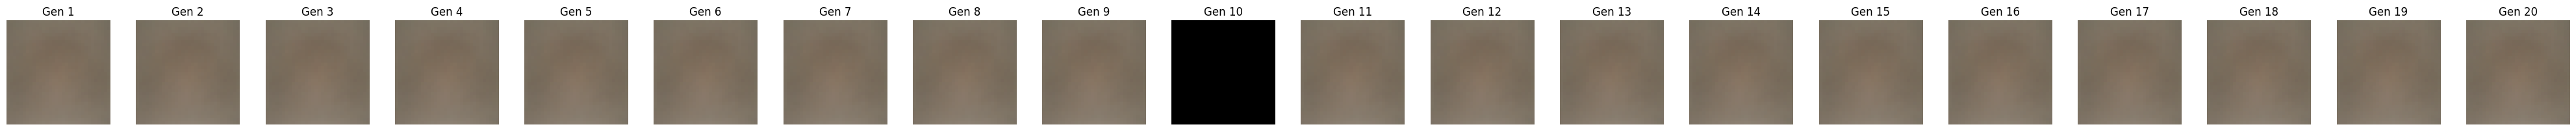

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt

checkpoint_path = "diffusion_deepmodel_model.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=torch.device('cpu')))
model.eval()

num_images_to_generate = 20

plt.figure(figsize=(num_images_to_generate * 2, 2))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

with torch.no_grad():
    for i in range(num_images_to_generate):
        alpha = np.random.rand() * 2
        beta = np.random.rand() * 2
        # Generate noisy image with 3 channels and 32x32 dimensions
        noisy_image_np = np.random.beta(alpha, beta, size=(3, 32, 32))
        noisy_image_tensor = torch.tensor(noisy_image_np, dtype=torch.float32).unsqueeze(0).to(device)

        # rand_index = torch.randint(0, 256, (1,), device=device) # This is not used in the current model forward
        # model_input = noisy_image_tensor.view(noisy_image_tensor.size(0), -1) # Remove flattening
        # model_input = torch.concat((model_input, rand_index.unsqueeze(1).float()), dim=1) # This concatenation is incorrect for the current model structure


        reconstructed_output = model(noisy_image_tensor) # Pass the image tensor directly
        # Reshape the output to match the image dimensions [batch_size, channels, height, width]
        reconstructed_tensor = reconstructed_output.view(noisy_image_tensor.size(0), 3, 32, 32)
        # Squeeze the batch dimension and move to CPU for plotting
        reconstructed_image = reconstructed_tensor.squeeze(0).cpu().numpy()

        plt.subplot(1, num_images_to_generate, i + 1)
        # Transpose the image from (C, H, W) to (H, W, C) for matplotlib
        plt.imshow(np.transpose(reconstructed_image, (1, 2, 0)))
        plt.title(f"Gen {i+1}")
        plt.axis('off')

plt.tight_layout()
plt.show()

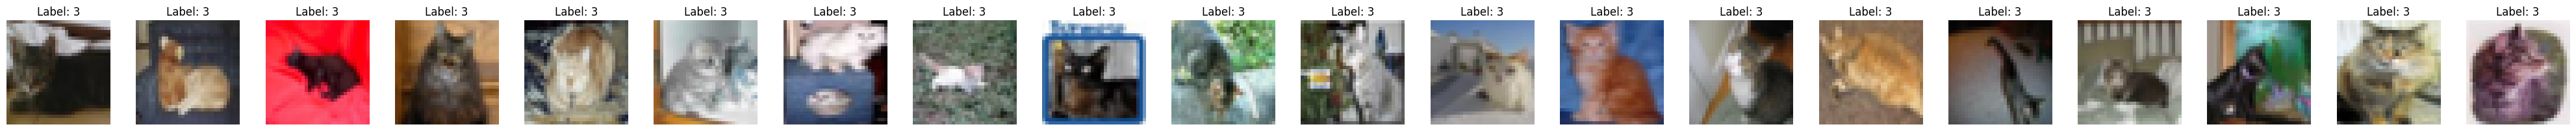

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Take a few images from the train_data_seven dataset
num_images_to_show = 20
plt.figure(figsize=(num_images_to_show * 2, 2))

for i in range(num_images_to_show):
    # Access the image and label from the dataset
    image, label = train_data_target_class[i]

    plt.subplot(1, num_images_to_show, i + 1)
    # Remove the channel dimension for displaying with matplotlib
    plt.imshow(np.transpose(image, (1, 2, 0)))
    plt.title(f"Label: {label}")
    plt.axis('off')

plt.tight_layout()
plt.show()